# Phase: Best ML Model — CatBoost / LightGBM Multiclass + Recall Optimization (Next 3 Hours)

**Goal:** Train a stronger multiclass model than Logistic Regression for forecasting the **next 3-hour block** collision risk class (0 / 1 / 2+), and apply **recall-focused threshold tuning** for the **High-risk class (Class 2)**.

**Input:** `processed_data/supervised_hood_3h_multiclass.csv`  
**Outputs (saved to `processed_data/`):**
- `best_ml_model.joblib` (LightGBM) **or** `best_ml_catboost.cbm` (CatBoost)
- `best_ml_features.txt`
- `best_ml_tau.txt`
- `best_ml_summary.csv`

> Recommended: Run **CatBoost first** (handles categorical HOOD cleanly, no scaling needed).


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score
import matplotlib.pyplot as plt

import joblib

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
SUPERVISED_PATH = DATA_DIR / "supervised_hood_3h_multiclass.csv"

# Optional: if you want to reuse selected features from the previous phase
SEL_FEATURES_PATH = DATA_DIR / "logreg_selected_top25_features.txt" 

# Outputs
OUT_SUMMARY = DATA_DIR / "best_ml_summary.csv"


In [4]:
# --- Load supervised dataset ---
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)
df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)
df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce").astype("int8")
df = df.sort_values(["time_3h", "HOOD_158_CODE"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Class distribution:")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))


Shape: (1383922, 50)
Class distribution:
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64


In [5]:
# --- Time-based split (same as earlier) ---
t = df["time_3h"]
train_end = pd.Timestamp("2024-12-31 23:59:59")
val_end   = pd.Timestamp("2025-06-30 23:59:59")

train_mask = t <= train_end
val_mask   = (t > train_end) & (t <= val_end)
test_mask  = t > val_end

# Build X/y
y = df["y_class"].copy()
X = df.drop(columns=[c for c in ["y_class", "y_count_next"] if c in df.columns], errors="ignore").copy()

# Do not use raw timestamp as a model feature (we already have time-derived features)
X = X.drop(columns=["time_3h"], errors="ignore")

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val     = X.loc[val_mask], y.loc[val_mask]
X_test, y_test   = X.loc[test_mask], y.loc[test_mask]

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)


Train/Val/Test: (922720, 47) (228784, 47) (232418, 47)


In [6]:
# --- Optionally use a selected feature list (keeps training faster & more interpretable) ---
use_selected_features = False  # set True if you want to use the top25 list file

if use_selected_features and SEL_FEATURES_PATH.exists():
    with open(SEL_FEATURES_PATH, "r") as f:
        sel = [line.strip() for line in f if line.strip()]
    # Keep only features that exist
    sel = [c for c in sel if c in X_train.columns]
    if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in sel:
        sel.append("HOOD_158_CODE")
    X_train = X_train[sel].copy()
    X_val   = X_val[sel].copy()
    X_test  = X_test[sel].copy()
    print("Using selected features:", len(sel))
else:
    sel = list(X_train.columns)
    print("Using all features:", len(sel))

# Identify categorical columns
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categorical:", cat_cols)
print("Numeric count:", len(num_cols))


Using all features: 47
Categorical: ['HOOD_158_CODE']
Numeric count: 46


In [7]:
# --- Evaluation helpers ---
def plot_confusion(cm, labels=(0,1,2), title="Confusion Matrix"):
    fig, ax = plt.subplots()
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

def eval_multiclass(y_true, y_pred, name="Model"):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    rec = recall_score(y_true, y_pred, labels=[0,1,2], average=None, zero_division=0)
    macro_rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    rec_high = recall_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)
    prec_high = precision_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)

    print(f"\n=== {name} ===")
    print("Per-class recall [0,1,2]:", np.round(rec, 4))
    print("Macro recall:", round(float(macro_rec), 4))
    print("High-risk recall:", round(float(rec_high), 4))
    print("High-risk precision:", round(float(prec_high), 4))
    print("\n", classification_report(y_true, y_pred, digits=4, zero_division=0))
    plot_confusion(cm, title=f"{name} Confusion Matrix")
    return {
        "recall_0": rec[0], "recall_1": rec[1], "recall_2": rec[2],
        "macro_recall": macro_rec, "recall_high": rec_high, "precision_high": prec_high
    }

def apply_highrisk_threshold(proba, tau, class2_index=2):
    """If P(class2)>=tau predict 2 else argmax among {0,1}."""
    p2 = proba[:, class2_index]
    pred01 = np.argmax(proba[:, [0,1]], axis=1)
    preds = pred01.copy()
    preds[p2 >= tau] = 2
    return preds

def choose_tau_by_constraint(proba, y_true, target_recall_high=0.80):
    taus = np.linspace(0.05, 0.95, 19)
    rows = []
    for tau in taus:
        pred = apply_highrisk_threshold(proba, tau, class2_index=2)
        rec_high = recall_score((y_true==2).astype(int), (pred==2).astype(int), zero_division=0)
        prec_high = precision_score((y_true==2).astype(int), (pred==2).astype(int), zero_division=0)
        macro_rec = recall_score(y_true, pred, average="macro", zero_division=0)
        rows.append((tau, rec_high, prec_high, macro_rec))
    tau_df = pd.DataFrame(rows, columns=["tau","recall_high","precision_high","macro_recall"]).sort_values("tau")
    candidates = tau_df[tau_df["recall_high"] >= target_recall_high].copy()
    if len(candidates) == 0:
        chosen = tau_df.sort_values(["macro_recall","recall_high"], ascending=False).iloc[0]
    else:
        chosen = candidates.sort_values(["macro_recall","precision_high"], ascending=False).iloc[0]
    return float(chosen["tau"]), tau_df


In [8]:
# --- Class weights (balanced) ---
# Weights help the rare class (2) get more attention.
class_counts = y_train.value_counts().sort_index()
total = class_counts.sum()
# sklearn-style "balanced": n_samples / (n_classes * count)
weights = (total / (3 * class_counts)).to_dict()
print("Class counts (train):")
print(class_counts)
print("Class weights:")
print(weights)


Class counts (train):
y_class
0    823183
1     86350
2     13187
Name: count, dtype: int64
Class weights:
{0: 0.373639073369267, 1: 3.561937849835939, 2: 23.323980688051364}


## A) CatBoost Multiclass (recommended)
CatBoost can directly use categorical features without one-hot encoding and typically performs very well on tabular data.


0:	learn: 1.0838589	test: 1.0840372	best: 1.0840372 (0)	total: 1.77s	remaining: 59m 1s
200:	learn: 0.8941782	test: 0.9216877	best: 0.9214965 (145)	total: 5m 4s	remaining: 45m 23s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9214964595
bestIteration = 145

Shrink model to first 146 iterations.

=== CatBoost Argmax - Val ===
Per-class recall [0,1,2]: [0.6499 0.3794 0.5981]
Macro recall: 0.5425
High-risk recall: 0.5981
High-risk precision: 0.0666

               precision    recall  f1-score   support

           0     0.9530    0.6499    0.7728    204791
           1     0.1311    0.3794    0.1948     20758
           2     0.0666    0.5981    0.1199      3235

    accuracy                         0.6246    228784
   macro avg     0.3836    0.5425    0.3625    228784
weighted avg     0.8659    0.6246    0.7111    228784



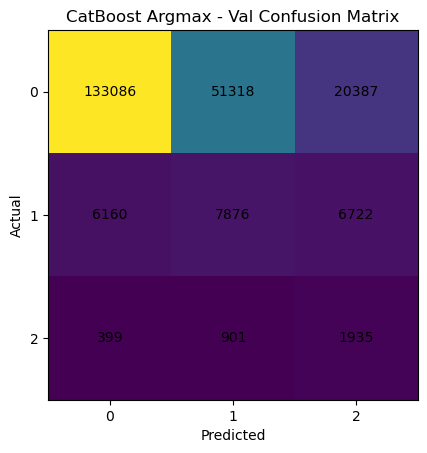


=== CatBoost Argmax - Test ===
Per-class recall [0,1,2]: [0.6324 0.3879 0.6253]
Macro recall: 0.5485
High-risk recall: 0.6253
High-risk precision: 0.0691

               precision    recall  f1-score   support

           0     0.9559    0.6324    0.7612    207818
           1     0.1283    0.3879    0.1928     21189
           2     0.0691    0.6253    0.1244      3411

    accuracy                         0.6100    232418
   macro avg     0.3844    0.5485    0.3595    232418
weighted avg     0.8674    0.6100    0.7000    232418



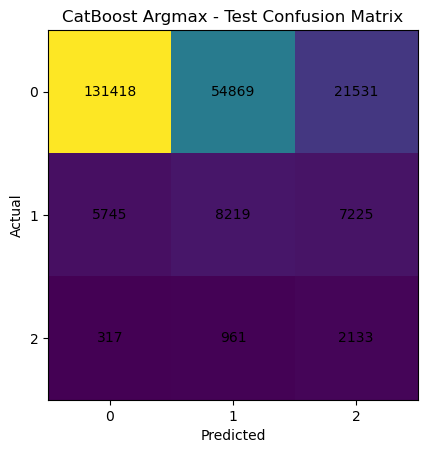

Chosen tau (CatBoost): 0.25

=== CatBoost Tuned (tau=0.25) - Test ===
Per-class recall [0,1,2]: [0.6297 0.1088 0.8432]
Macro recall: 0.5272
High-risk recall: 0.8432
High-risk precision: 0.0393

               precision    recall  f1-score   support

           0     0.9561    0.6297    0.7593    207818
           1     0.1035    0.1088    0.1061     21189
           2     0.0393    0.8432    0.0750      3411

    accuracy                         0.5854    232418
   macro avg     0.3663    0.5272    0.3135    232418
weighted avg     0.8649    0.5854    0.6897    232418



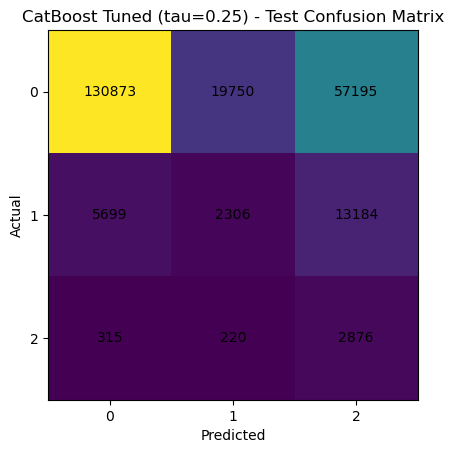

Saved: ..\data\processed\best_ml_catboost.cbm
Saved: ..\data\processed\best_ml_catboost_tau.txt
Saved: ..\data\processed\best_ml_catboost_features.txt


In [11]:
# --- CatBoost training ---
try:
    from catboost import CatBoostClassifier
    catboost_available = True
except Exception as e:
    catboost_available = False
    print("CatBoost not available:", e)

results = []

if catboost_available:
    # Identify categorical feature indices for CatBoost
    # CatBoost expects column indices in the training dataframe
    cat_features = [X_train.columns.get_loc(c) for c in cat_cols]

    cb = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="MultiClass",
        iterations=2000,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3.0,
        random_seed=42,
        verbose=200,
        class_weights=[weights.get(0,1.0), weights.get(1,1.0), weights.get(2,1.0)],
        od_type="Iter",          # early stopping
        od_wait=200
    )

    cb.fit(
        X_train, y_train,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    # Argmax evaluation
    pred_val_cb = cb.predict(X_val).reshape(-1).astype(int)
    metrics_val = eval_multiclass(y_val, pred_val_cb, name="CatBoost Argmax - Val")

    pred_test_cb = cb.predict(X_test).reshape(-1).astype(int)
    metrics_test = eval_multiclass(y_test, pred_test_cb, name="CatBoost Argmax - Test")

    # Threshold tuning (High-risk)
    proba_val_cb = cb.predict_proba(X_val)
    best_tau_cb, tau_df_cb = choose_tau_by_constraint(proba_val_cb, y_val, target_recall_high=0.80)
    print("Chosen tau (CatBoost):", best_tau_cb)

    pred_test_cb_tuned = apply_highrisk_threshold(cb.predict_proba(X_test), best_tau_cb, class2_index=2)
    metrics_test_tuned = eval_multiclass(y_test, pred_test_cb_tuned, name=f"CatBoost Tuned (tau={best_tau_cb:.2f}) - Test")

    # Save CatBoost model
    OUT_CB = DATA_DIR / "best_ml_catboost.cbm"
    cb.save_model(str(OUT_CB))

    # Save tau + features
    OUT_CB_TAU = DATA_DIR / "best_ml_catboost_tau.txt"
    with open(OUT_CB_TAU, "w") as f:
        f.write(str(best_tau_cb))

    OUT_CB_FEATS = DATA_DIR / "best_ml_catboost_features.txt"
    with open(OUT_CB_FEATS, "w") as f:
        for c in X_train.columns:
            f.write(c + "\n")

    results.append({
        "model": "CatBoost Argmax", **metrics_test
    })
    results.append({
        "model": f"CatBoost Tuned tau={best_tau_cb:.2f}", **metrics_test_tuned
    })

    print("Saved:", OUT_CB)
    print("Saved:", OUT_CB_TAU)
    print("Saved:", OUT_CB_FEATS)


## B) LightGBM Multiclass (optional alternative)

LightGBM usually needs categorical features encoded. We use one-hot encoding via a preprocessing pipeline.  
No scaling is required for tree models, but keeping numeric imputation is important.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2806
[LightGBM] [Info] Number of data points in the train set: 922720, number of used features: 204
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


c:\Users\Jigme\anaconda3\envs\tcr\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM Argmax - Val ===
Per-class recall [0,1,2]: [0.7093 0.4756 0.2881]
Macro recall: 0.491
High-risk recall: 0.2881
High-risk precision: 0.0752

               precision    recall  f1-score   support

           0     0.9445    0.7093    0.8102    204791
           1     0.1577    0.4756    0.2369     20758
           2     0.0752    0.2881    0.1193      3235

    accuracy                         0.6821    228784
   macro avg     0.3925    0.4910    0.3888    228784
weighted avg     0.8608    0.6821    0.7484    228784



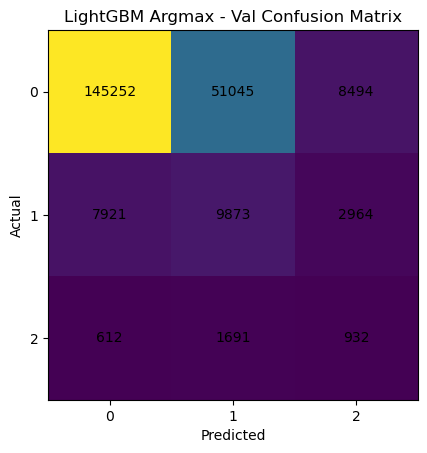

c:\Users\Jigme\anaconda3\envs\tcr\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM Argmax - Test ===
Per-class recall [0,1,2]: [0.6826 0.4861 0.3635]
Macro recall: 0.5108
High-risk recall: 0.3635
High-risk precision: 0.0822

               precision    recall  f1-score   support

           0     0.9484    0.6826    0.7939    207818
           1     0.1520    0.4861    0.2316     21189
           2     0.0822    0.3635    0.1341      3411

    accuracy                         0.6600    232418
   macro avg     0.3942    0.5108    0.3865    232418
weighted avg     0.8631    0.6600    0.7329    232418



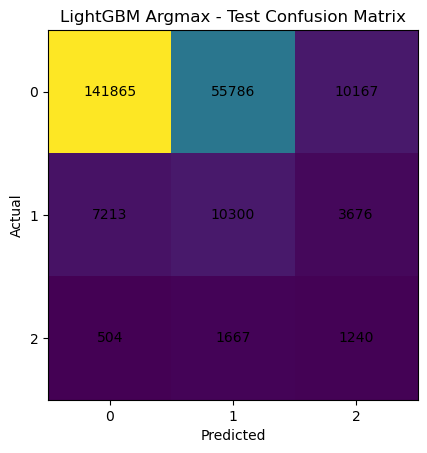

c:\Users\Jigme\anaconda3\envs\tcr\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Chosen tau (LightGBM): 0.1


c:\Users\Jigme\anaconda3\envs\tcr\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM Tuned (tau=0.10) - Test ===
Per-class recall [0,1,2]: [0.5771 0.0851 0.8751]
Macro recall: 0.5124
High-risk recall: 0.8751
High-risk precision: 0.033

               precision    recall  f1-score   support

           0     0.9588    0.5771    0.7205    207818
           1     0.1070    0.0851    0.0948     21189
           2     0.0330    0.8751    0.0636      3411

    accuracy                         0.5366    232418
   macro avg     0.3662    0.5124    0.2930    232418
weighted avg     0.8675    0.5366    0.6538    232418



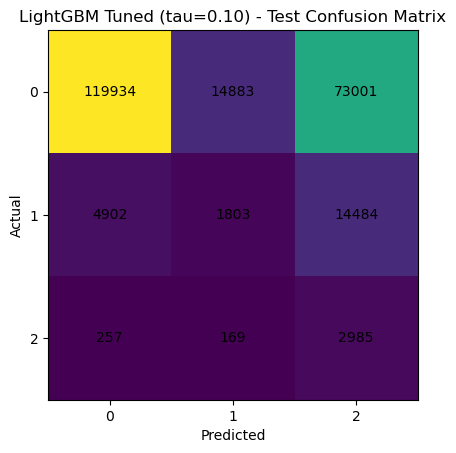

Saved: ..\data\processed\best_ml_lightgbm.joblib
Saved: ..\data\processed\best_ml_lightgbm_tau.txt
Saved: ..\data\processed\best_ml_lightgbm_features.txt


In [12]:
# --- LightGBM training ---
try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except Exception as e:
    lgbm_available = False
    print("LightGBM not available:", e)

if lgbm_available:
    # Preprocess: impute numeric + one-hot categorical (NO scaler needed for trees)
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.impute import SimpleImputer

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess_lgbm = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ],
        remainder="drop"
    )

    lgbm = LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=2000,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        class_weight=weights,   # handles imbalance
        n_jobs=-1
    )

    lgbm_pipe = Pipeline(steps=[
        ("preprocess", preprocess_lgbm),
        ("model", lgbm)
    ])

    # Fit with early stopping using validation (LightGBM supports it via callbacks in recent versions)
    lgbm_pipe.fit(X_train, y_train)

    # Argmax evaluation
    pred_val_lgbm = lgbm_pipe.predict(X_val)
    metrics_val = eval_multiclass(y_val, pred_val_lgbm, name="LightGBM Argmax - Val")

    pred_test_lgbm = lgbm_pipe.predict(X_test)
    metrics_test = eval_multiclass(y_test, pred_test_lgbm, name="LightGBM Argmax - Test")

    # Threshold tuning (High-risk)
    proba_val_lgbm = lgbm_pipe.predict_proba(X_val)
    best_tau_lgbm, tau_df_lgbm = choose_tau_by_constraint(proba_val_lgbm, y_val, target_recall_high=0.80)
    print("Chosen tau (LightGBM):", best_tau_lgbm)

    proba_test_lgbm = lgbm_pipe.predict_proba(X_test)
    pred_test_lgbm_tuned = apply_highrisk_threshold(proba_test_lgbm, best_tau_lgbm, class2_index=2)
    metrics_test_tuned = eval_multiclass(y_test, pred_test_lgbm_tuned, name=f"LightGBM Tuned (tau={best_tau_lgbm:.2f}) - Test")

    # Save model
    OUT_LGBM = DATA_DIR / "best_ml_lightgbm.joblib"
    joblib.dump(lgbm_pipe, OUT_LGBM)

    OUT_LGBM_TAU = DATA_DIR / "best_ml_lightgbm_tau.txt"
    with open(OUT_LGBM_TAU, "w") as f:
        f.write(str(best_tau_lgbm))

    OUT_LGBM_FEATS = DATA_DIR / "best_ml_lightgbm_features.txt"
    with open(OUT_LGBM_FEATS, "w") as f:
        for c in X_train.columns:
            f.write(c + "\n")

    results.append({
        "model": "LightGBM Argmax", **metrics_test
    })
    results.append({
        "model": f"LightGBM Tuned tau={best_tau_lgbm:.2f}", **metrics_test_tuned
    })

    print("Saved:", OUT_LGBM)
    print("Saved:", OUT_LGBM_TAU)
    print("Saved:", OUT_LGBM_FEATS)


In [13]:
# --- Compare models (Test metrics summary) ---
summary = pd.DataFrame(results)
if len(summary):
    summary = summary[["model","macro_recall","recall_high","precision_high","recall_0","recall_1","recall_2"]]
    summary = summary.sort_values(["recall_high","macro_recall"], ascending=False)
    print(summary)
    summary.to_csv(OUT_SUMMARY, index=False)
    print("Saved:", OUT_SUMMARY)
else:
    print("No ML models ran (install catboost/lightgbm and rerun).")


                     model  macro_recall  recall_high  precision_high  \
3  LightGBM Tuned tau=0.10      0.512437     0.875110        0.032994   
1  CatBoost Tuned tau=0.25      0.527244     0.843155        0.039260   
0          CatBoost Argmax      0.548530     0.625330        0.069054   
2          LightGBM Argmax      0.510757     0.363530        0.082212   

   recall_0  recall_1  recall_2  
3  0.577111  0.085091  0.875110  
1  0.629748  0.108830  0.843155  
0  0.632371  0.387890  0.625330  
2  0.682641  0.486101  0.363530  
Saved: ..\data\processed\best_ml_summary.csv
